# DSS Q3 — Cervical Cancer Risk: Sensitivity Analysis

**Inputs:** `cervical_model_bundle.joblib` from `02_model.ipynb`  
**Goal:** Understand how robust the ensemble's predictions and confidence scores are when key inputs are uncertain, misreported, or missing. Each analysis directly maps to a real clinical scenario.

### Notebook structure
1. Setup & load bundle  
2. Baseline prediction distribution  
3. **STD misreporting** — what if patients under-report STD history?  
4. **Smoker status uncertainty** — how much does unknown smoking shift risk?  
5. **IUD protective effect** — what if IUD duration is mis-recorded?  
6. **Age sensitivity** — how risk changes across the age spectrum  
7. **Feature ablation** — how much does each feature contribute to predictions?  
8. **Cluster-level sensitivity** — per risk-segment impact of input perturbations  
9. **Confidence score stress test** — which inputs destabilise confidence most?  
10. **Missing data simulation** — what if N features are unknown at inference time?  
11. Key findings summary for DSS intervention rules  

---
## 1. Setup & Load Bundle

In [1]:
import warnings, json
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

SEED      = 42
np.random.seed(SEED)
PLOTS_DIR = Path('sensitivity_plots')
PLOTS_DIR.mkdir(exist_ok=True)

# ── Load bundle ───────────────────────────────────────────────────────────────
bundle = joblib.load('cervical_model_bundle.joblib')

MODELS         = bundle['models']           # {name: fitted pipeline}
MODEL_NAMES    = bundle['model_names']
ENS_WEIGHTS    = bundle['ensemble_weights']
FEATURES       = bundle['feature_names']    # No-Dx feature set
THRESHOLD      = bundle['threshold']
CONF_WEIGHTS   = bundle['conf_weights']
CENTROIDS      = bundle['centroids']
SCALER_CONF    = bundle['scaler_conf']
DEMO_POS       = bundle['demo_pos']
KM_MODEL       = bundle['km_model']
KM_SCALER      = bundle['km_scaler']
CLUSTER_FEATS  = bundle['cluster_features']

print(f'Bundle loaded ✓')
print(f'Models: {MODEL_NAMES}')
print(f'Features: {FEATURES}')
print(f'Decision threshold: {THRESHOLD:.3f}')

Bundle loaded ✓
Models: ['LR', 'RF', 'XGB', 'SVM']
Features: ['Age', 'Number of sexual partners', 'Num of pregnancies', 'Smokes (years)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STD_burden', 'Cluster']
Decision threshold: 0.072


In [2]:
# ── Reload & clean dataset (same pipeline as 02_model.ipynb) ─────────────────
from sklearn.cluster import KMeans

df_raw   = pd.read_csv('risk_factors_cervical_cancer.csv', na_values='?')
OUTCOMES = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']

missing_pct = df_raw.isnull().mean()
df = df_raw.drop(columns=missing_pct[missing_pct > 0.50].index.tolist())

feature_cols    = [c for c in df.columns if c not in OUTCOMES]
binary_cols     = [c for c in feature_cols if df[c].dropna().isin([0.0,1.0]).all()]
continuous_cols = [c for c in feature_cols if c not in binary_cols]

for col in continuous_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median())
for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].mode()[0])

df['AnyAbnormal'] = df[OUTCOMES].max(axis=1).astype(int)
std_cols = [c for c in df.columns if c.startswith('STDs:') and c != 'STDs: Number of diagnosis']
df['STD_burden'] = df[std_cols].sum(axis=1)
df['AgeBucket']  = pd.cut(df['Age'], bins=[0,19,29,39,49,100],
                           labels=['<20','20-29','30-39','40-49','50+'])

cluster_biopsy = {c: df[KM_MODEL.labels_ == c]['Biopsy'].mean() for c in range(3)}
rank_map       = {c: r for r, c in enumerate(sorted(cluster_biopsy, key=cluster_biopsy.get))}
df['Cluster']   = pd.Series(KM_MODEL.labels_).map(rank_map).values

X    = df[FEATURES].copy()
y    = df['Biopsy'].values
print(f'Dataset: {X.shape}  |  Positive rate: {y.mean():.1%}')

Dataset: (858, 8)  |  Positive rate: 6.4%


In [3]:
# ── Core inference helpers ────────────────────────────────────────────────────

def ensemble_proba(X_input: pd.DataFrame) -> np.ndarray:
    """Returns (n_samples,) array of ensemble positive-class probabilities."""
    probs = np.column_stack([
        MODELS[n].predict_proba(X_input)[:, 1] for n in MODEL_NAMES
    ])
    return probs @ ENS_WEIGHTS


def individual_probas(X_input: pd.DataFrame) -> dict:
    """Returns {model_name: (n_samples,) array}."""
    return {n: MODELS[n].predict_proba(X_input)[:, 1] for n in MODEL_NAMES}


def _binary_entropy_norm(p):
    eps = 1e-9
    p   = np.clip(p, eps, 1-eps)
    H   = -(p*np.log(p) + (1-p)*np.log(1-p))
    return H / np.log(2)


def compute_confidence_batch(X_input: pd.DataFrame, ens_p: np.ndarray,
                              ind_p: dict) -> np.ndarray:
    """
    Vectorised confidence score for a batch of rows.
    Returns (n_samples,) array of confidence scores.
    """
    a, b, c, d, e, f = CONF_WEIGHTS
    X_s        = SCALER_CONF.transform(X_input)
    pred_cls   = (ens_p >= THRESHOLD).astype(int)

    scores = np.zeros(len(X_input))
    for i in range(len(X_input)):
        pc   = pred_cls[i]
        p    = float(ens_p[i])
        row  = X_s[[i]]

        x    = max(0.0, float(cosine_similarity(row, CENTROIDS[pc].reshape(1,-1))[0,0]))
        y_s  = p if pc == 1 else 1.0 - p

        opp     = 1 - pc
        cos_opp = max(0.0, float(cosine_similarity(row, CENTROIDS[opp].reshape(1,-1))[0,0]))
        z       = (1.0 - p) * cos_opp

        age_z = abs(X_input.iloc[i]['Age'] - DEMO_POS['age_mean']) / (DEMO_POS['age_std'] + 1e-6)
        m     = max(0.0, 1.0 - age_z / 3.0) if pc == 1 else \
                float(np.clip(1.0 - age_z / (3.0 * DEMO_POS['age_std'] + 1e-6), 0, 1))

        H         = float(_binary_entropy_norm(p))
        votes     = [int((float(ind_p[n][i]) >= 0.5) == pc) for n in MODEL_NAMES]
        agreement = float(np.mean(votes))

        scores[i] = np.clip(a*x + b*y_s - c*z + d*m + e*(1-H) + f*agreement, 0, 1)
    return scores


# Baseline — compute once
BASE_ENS_P  = ensemble_proba(X)
BASE_IND_P  = individual_probas(X)
BASE_CONF   = compute_confidence_batch(X, BASE_ENS_P, BASE_IND_P)
BASE_PRED   = (BASE_ENS_P >= THRESHOLD).astype(int)

print(f'Baseline  —  mean prob: {BASE_ENS_P.mean():.4f}')
print(f'Baseline  —  positive predictions: {BASE_PRED.sum()} ({BASE_PRED.mean():.1%})')
print(f'Baseline  —  mean confidence: {BASE_CONF.mean():.4f}')

Baseline  —  mean prob: 0.2060
Baseline  —  positive predictions: 695 (81.0%)
Baseline  —  mean confidence: 0.3632


---
## 2. Baseline Prediction Distribution

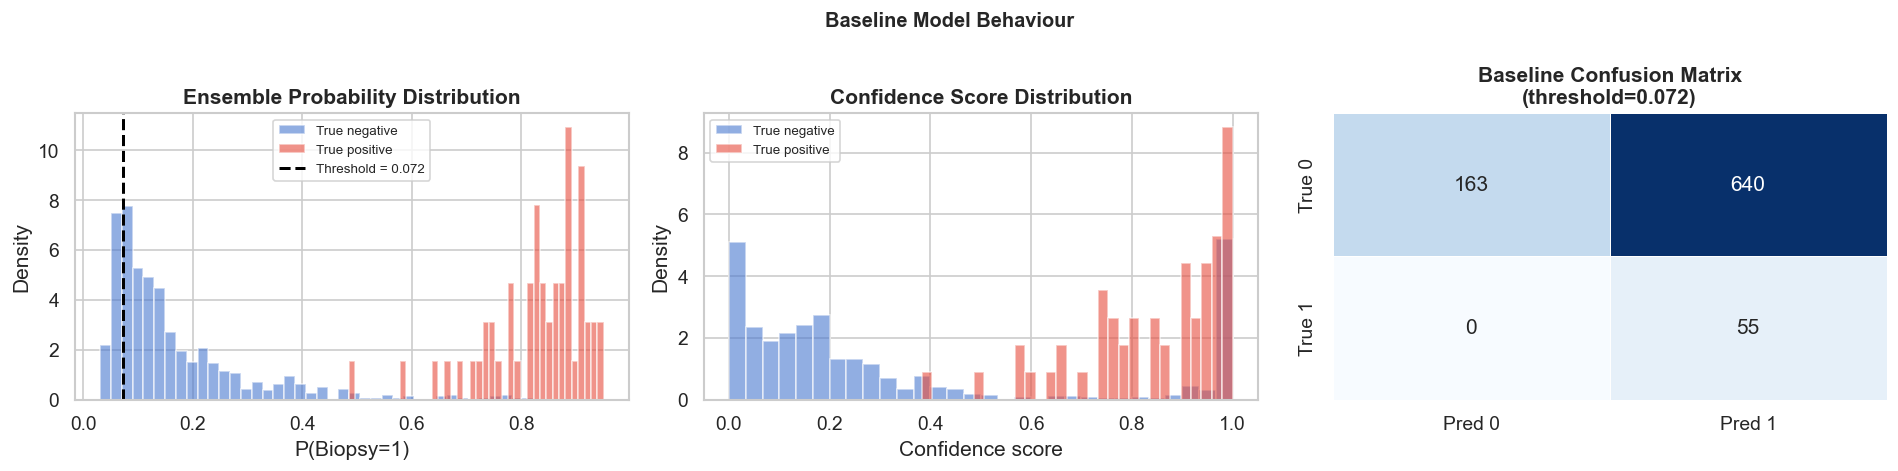

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Probability histogram
axes[0].hist(BASE_ENS_P[y==0], bins=40, alpha=0.6, color='#4878CF',
             label='True negative', density=True)
axes[0].hist(BASE_ENS_P[y==1], bins=40, alpha=0.6, color='#E74C3C',
             label='True positive', density=True)
axes[0].axvline(THRESHOLD, color='black', ls='--', lw=1.8,
                label=f'Threshold = {THRESHOLD:.3f}')
axes[0].set_title('Ensemble Probability Distribution', fontweight='bold')
axes[0].set_xlabel('P(Biopsy=1)'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Confidence histogram
axes[1].hist(BASE_CONF[y==0], bins=30, alpha=0.6, color='#4878CF',
             label='True negative', density=True)
axes[1].hist(BASE_CONF[y==1], bins=30, alpha=0.6, color='#E74C3C',
             label='True positive', density=True)
axes[1].set_title('Confidence Score Distribution', fontweight='bold')
axes[1].set_xlabel('Confidence score'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# Prediction vs truth
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, BASE_PRED)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'],
            cbar=False, linewidths=0.5)
axes[2].set_title(f'Baseline Confusion Matrix\n(threshold={THRESHOLD:.3f})', fontweight='bold')

plt.suptitle('Baseline Model Behaviour', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'baseline_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 3. STD Misreporting Sensitivity

**Clinical scenario:** Patients frequently under-report STD history due to stigma.  
We simulate this by progressively zeroing out `STD_burden` for a fraction of patients and measuring how many risk classifications flip from high to low.

If ALL patients report STD_burden = 0:
  Original high-risk count:  695
  New high-risk count:       691
  Patients flipped to low:   4  (0.6% of original high-risk)
  Mean prob change:          -0.0055


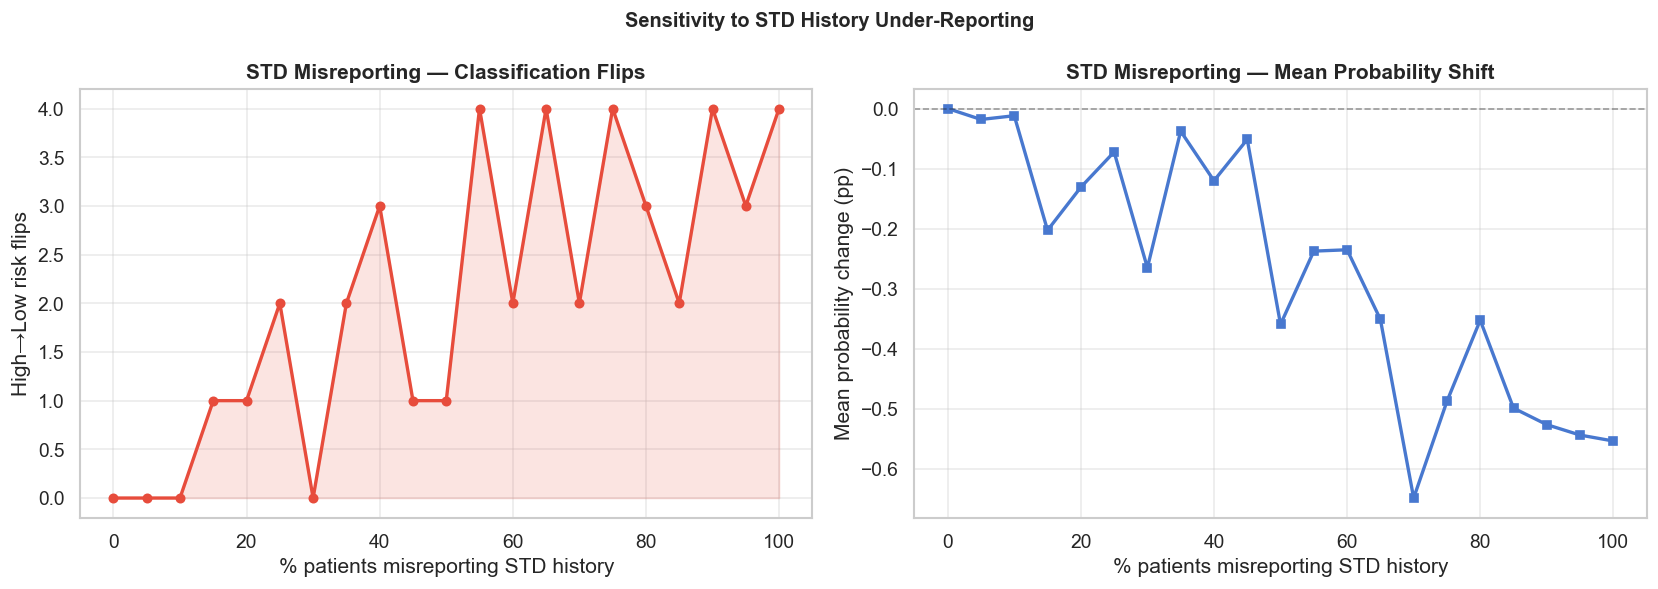

In [5]:
# ── Scenario A: Zero out STD_burden entirely for all patients ─────────────────
X_no_std            = X.copy()
X_no_std['STD_burden'] = 0.0

p_no_std   = ensemble_proba(X_no_std)
pred_no_std = (p_no_std >= THRESHOLD).astype(int)
flipped     = ((BASE_PRED == 1) & (pred_no_std == 0)).sum()

print(f'If ALL patients report STD_burden = 0:')
print(f'  Original high-risk count:  {BASE_PRED.sum()}')
print(f'  New high-risk count:       {pred_no_std.sum()}')
print(f'  Patients flipped to low:   {flipped}  ({flipped/BASE_PRED.sum():.1%} of original high-risk)')
print(f'  Mean prob change:          {(p_no_std - BASE_ENS_P).mean():+.4f}')

# ── Scenario B: Misreporting rate sweep ───────────────────────────────────────
misreport_rates = np.arange(0, 1.05, 0.05)
flip_counts, prob_deltas = [], []

rng = np.random.default_rng(SEED)
for rate in misreport_rates:
    X_perturb = X.copy()
    mask = rng.random(len(X)) < rate
    X_perturb.loc[mask, 'STD_burden'] = 0.0
    p_perturb  = ensemble_proba(X_perturb)
    pred_perturb = (p_perturb >= THRESHOLD).astype(int)
    flip_counts.append(((BASE_PRED == 1) & (pred_perturb == 0)).sum())
    prob_deltas.append((p_perturb - BASE_ENS_P).mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(misreport_rates*100, flip_counts, 'o-', color='#E74C3C', lw=2, markersize=5)
axes[0].fill_between(misreport_rates*100, flip_counts, alpha=0.15, color='#E74C3C')
axes[0].set_xlabel('% patients misreporting STD history'); axes[0].set_ylabel('High→Low risk flips')
axes[0].set_title('STD Misreporting — Classification Flips', fontweight='bold')
axes[0].grid(True, alpha=0.4)

axes[1].plot(misreport_rates*100, np.array(prob_deltas)*100, 's-', color='#4878CF', lw=2, markersize=5)
axes[1].axhline(0, color='k', lw=1, ls='--', alpha=0.4)
axes[1].set_xlabel('% patients misreporting STD history')
axes[1].set_ylabel('Mean probability change (pp)')
axes[1].set_title('STD Misreporting — Mean Probability Shift', fontweight='bold')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Sensitivity to STD History Under-Reporting', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'std_misreporting.png', dpi=130, bbox_inches='tight')
plt.show()

In [6]:
# ── STD burden scaling — partial misreport (not full zeroing) ─────────────────
# e.g., patient reports half their actual STD history
scale_factors = [1.0, 0.75, 0.50, 0.25, 0.0]
results_scale = {}

for sf in scale_factors:
    X_s = X.copy()
    X_s['STD_burden'] = X_s['STD_burden'] * sf
    p_s = ensemble_proba(X_s)
    results_scale[sf] = {
        'mean_prob':    float(p_s.mean()),
        'high_risk_n':  int((p_s >= THRESHOLD).sum()),
        'prob_delta_pp': float((p_s - BASE_ENS_P).mean() * 100),
    }

scale_df = pd.DataFrame(results_scale).T
scale_df.index.name = 'STD_burden scale factor'
print('\nPartial STD misreporting effect:')
print(scale_df.round(4).to_string())
print('\nInsight for DSS: Flag predictions where STD_burden = 0 but other indicators suggest risk.')


Partial STD misreporting effect:
                         mean_prob  high_risk_n  prob_delta_pp
STD_burden scale factor                                       
1.00                        0.2060        695.0        -0.0000
0.75                        0.2081        695.0         0.2124
0.50                        0.2081        695.0         0.2082
0.25                        0.2115        695.0         0.5510
0.00                        0.2005        691.0        -0.5534

Insight for DSS: Flag predictions where STD_burden = 0 but other indicators suggest risk.


---
## 4. Smoker Status Uncertainty

**Clinical scenario:** Patients may not disclose or accurately recall smoking history.  
We test what happens when `Smokes (years)` is unknown (set to 0) vs over-reported.

Smoking sensitivity results:
                   mean_prob  high_risk_n  delta_pp  flips_to_high  flips_to_low
Baseline              0.2060        695.0    -0.000            0.0           0.0
Unknown (→ 0)         0.2041        702.0    -0.189           13.0           6.0
Median imputed        0.2041        702.0    -0.189           13.0           6.0
+5 years              0.2277        677.0     2.164           42.0          60.0
+10 years             0.1916        571.0    -1.442           28.0         152.0
Heavy smoker (20)     0.1783        556.0    -2.772           34.0         173.0


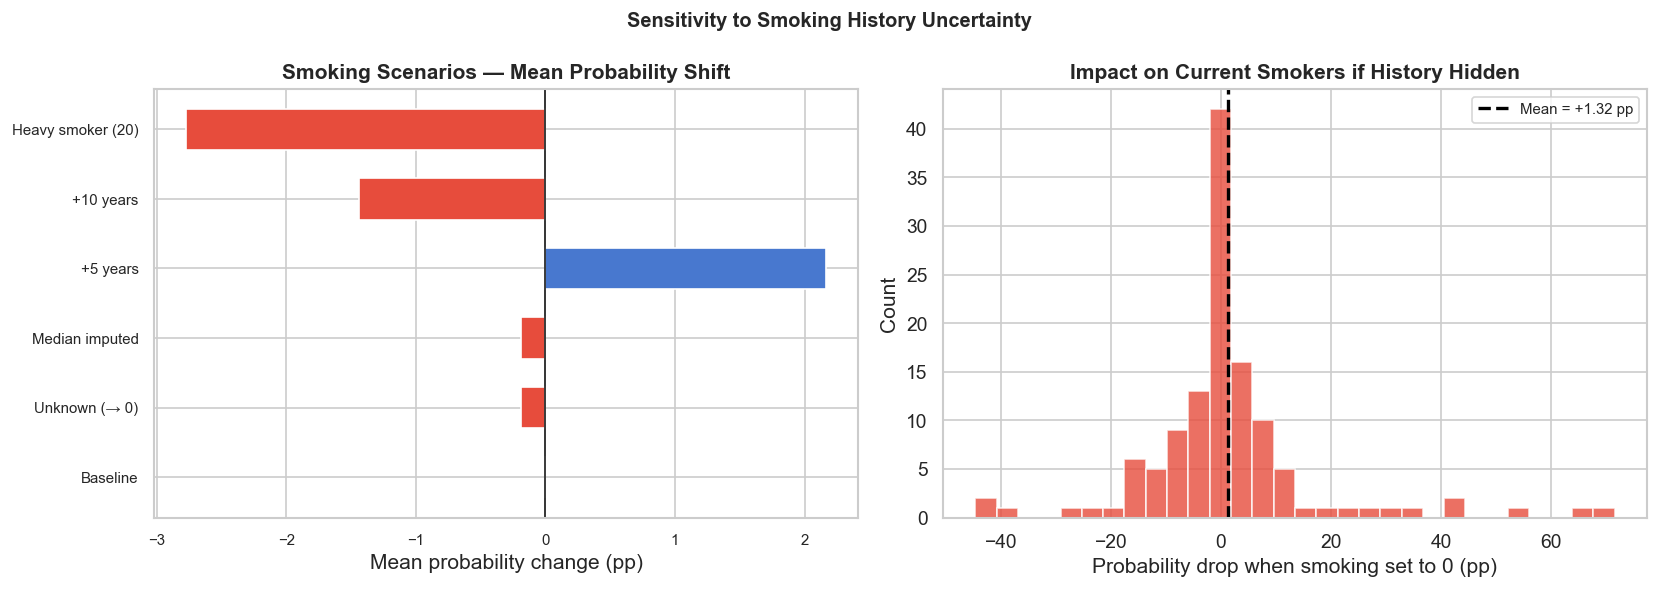

In [7]:
smoke_scenarios = {
    'Baseline':          X['Smokes (years)'],
    'Unknown (→ 0)':     np.zeros(len(X)),
    'Median imputed':    np.full(len(X), X['Smokes (years)'].median()),
    '+5 years':          np.clip(X['Smokes (years)'] + 5, 0, None),
    '+10 years':         np.clip(X['Smokes (years)'] + 10, 0, None),
    'Heavy smoker (20)': np.full(len(X), 20.0),
}

smoke_results = {}
for label, vals in smoke_scenarios.items():
    X_sc = X.copy()
    X_sc['Smokes (years)'] = vals
    p_sc = ensemble_proba(X_sc)
    smoke_results[label] = {
        'mean_prob':      round(float(p_sc.mean()), 4),
        'high_risk_n':    int((p_sc >= THRESHOLD).sum()),
        'delta_pp':       round(float((p_sc - BASE_ENS_P).mean() * 100), 3),
        'flips_to_high':  int(((BASE_PRED==0) & (p_sc>=THRESHOLD)).sum()),
        'flips_to_low':   int(((BASE_PRED==1) & (p_sc< THRESHOLD)).sum()),
    }

smoke_df = pd.DataFrame(smoke_results).T
print('Smoking sensitivity results:')
print(smoke_df.to_string())

# ── Per-patient delta for current smokers ─────────────────────────────────────
smoker_mask = X['Smokes (years)'] > 0
X_nosm = X.copy(); X_nosm.loc[smoker_mask, 'Smokes (years)'] = 0
p_nosm = ensemble_proba(X_nosm)
delta_smokers = (BASE_ENS_P - p_nosm)[smoker_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of scenarios
labels = list(smoke_results.keys())
deltas = [smoke_results[l]['delta_pp'] for l in labels]
colors_bar = ['#4878CF' if d >= 0 else '#E74C3C' for d in deltas]
axes[0].barh(labels, deltas, color=colors_bar, edgecolor='white', height=0.6)
axes[0].axvline(0, color='k', lw=1)
axes[0].set_xlabel('Mean probability change (pp)')
axes[0].set_title('Smoking Scenarios — Mean Probability Shift', fontweight='bold')
axes[0].tick_params(labelsize=9)

# Distribution of individual impact among actual smokers
axes[1].hist(delta_smokers * 100, bins=30, color='#E74C3C', edgecolor='white', alpha=0.8)
axes[1].axvline(delta_smokers.mean()*100, color='black', ls='--', lw=2,
                label=f'Mean = {delta_smokers.mean()*100:+.2f} pp')
axes[1].set_xlabel('Probability drop when smoking set to 0 (pp)')
axes[1].set_ylabel('Count')
axes[1].set_title('Impact on Current Smokers if History Hidden', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Sensitivity to Smoking History Uncertainty', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'smoking_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 5. IUD Protective Effect — Recording Accuracy

**Clinical scenario:** IUD duration can be poorly documented. The EDA showed IUD has a slight protective (negative) association with abnormal outcomes.  
We test what happens when IUD duration is zeroed (not recorded) vs inflated.

IUD users in dataset: 83 (9.7%)

IUD sensitivity results:
                             mean_prob  high_risk_n  delta_pp  flips_to_high  flips_to_low
Baseline                        0.2060        695.0    -0.000            0.0           0.0
IUD not recorded (→0)           0.2052        698.0    -0.083            9.0           6.0
IUD doubled                     0.2048        695.0    -0.120            2.0           2.0
IUD halved                      0.2098        702.0     0.374            8.0           1.0
All patients have IUD (5yr)     0.1752        589.0    -3.082           28.0         134.0


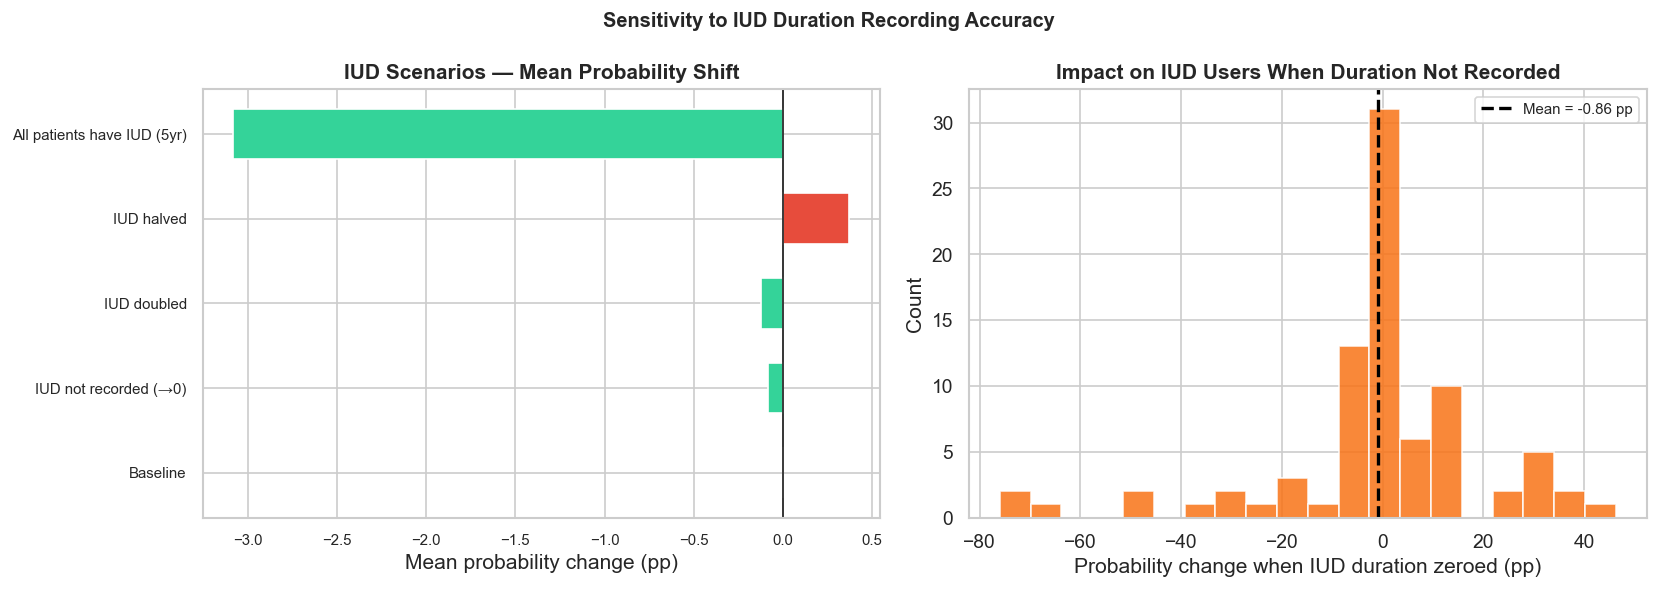

In [8]:
iud_users = X['IUD (years)'] > 0
print(f'IUD users in dataset: {iud_users.sum()} ({iud_users.mean():.1%})')

iud_scenarios = {
    'Baseline':              X['IUD (years)'],
    'IUD not recorded (→0)': np.zeros(len(X)),
    'IUD doubled':           X['IUD (years)'] * 2,
    'IUD halved':            X['IUD (years)'] * 0.5,
    'All patients have IUD (5yr)': np.full(len(X), 5.0),
}

iud_results = {}
for label, vals in iud_scenarios.items():
    X_iud = X.copy()
    X_iud['IUD (years)'] = vals
    p_iud = ensemble_proba(X_iud)
    iud_results[label] = {
        'mean_prob':     round(float(p_iud.mean()), 4),
        'high_risk_n':   int((p_iud >= THRESHOLD).sum()),
        'delta_pp':      round(float((p_iud - BASE_ENS_P).mean() * 100), 3),
        'flips_to_high': int(((BASE_PRED==0) & (p_iud>=THRESHOLD)).sum()),
        'flips_to_low':  int(((BASE_PRED==1) & (p_iud< THRESHOLD)).sum()),
    }

iud_df = pd.DataFrame(iud_results).T
print('\nIUD sensitivity results:')
print(iud_df.to_string())

# Focus: impact on IUD users only when duration is zeroed
X_iud_zero = X.copy(); X_iud_zero['IUD (years)'] = 0
p_iud_zero = ensemble_proba(X_iud_zero)
delta_iud  = (p_iud_zero - BASE_ENS_P)[iud_users]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = list(iud_results.keys())
deltas = [iud_results[l]['delta_pp'] for l in labels]
cols   = ['#E74C3C' if d > 0 else '#34d399' for d in deltas]
axes[0].barh(labels, deltas, color=cols, edgecolor='white', height=0.6)
axes[0].axvline(0, color='k', lw=1)
axes[0].set_xlabel('Mean probability change (pp)')
axes[0].set_title('IUD Scenarios — Mean Probability Shift', fontweight='bold')
axes[0].tick_params(labelsize=9)

axes[1].hist(delta_iud * 100, bins=20, color='#f97316', edgecolor='white', alpha=0.85)
axes[1].axvline(delta_iud.mean()*100, color='black', ls='--', lw=2,
                label=f'Mean = {delta_iud.mean()*100:+.2f} pp')
axes[1].set_xlabel('Probability change when IUD duration zeroed (pp)')
axes[1].set_ylabel('Count')
axes[1].set_title('Impact on IUD Users When Duration Not Recorded', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Sensitivity to IUD Duration Recording Accuracy', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'iud_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 6. Age Sensitivity

Age is one of the strongest risk factors. Here we test how predicted risk changes as a patient ages, holding all other features at their median values.

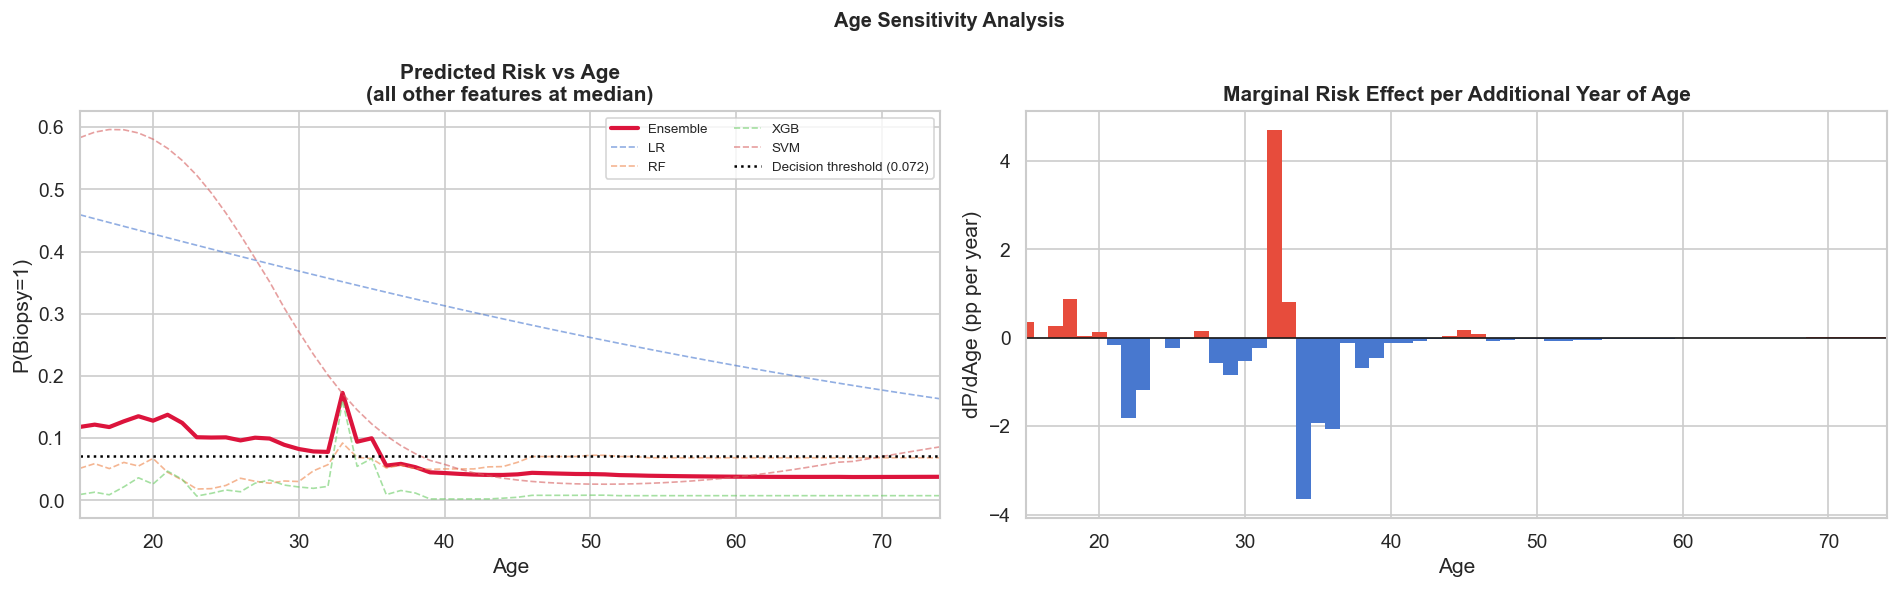


Risk crosses decision threshold at age ~15
Peak risk age: 33
Max predicted probability: 0.1728


In [9]:
age_range = np.arange(15, 75, 1)

# Build a median synthetic patient, vary age only
median_patient = X.median().to_dict()

age_results = []
for age in age_range:
    row = pd.DataFrame([{**median_patient, 'Age': float(age)}])[FEATURES]
    p   = float(ensemble_proba(row)[0])
    ind = {n: float(MODELS[n].predict_proba(row)[0, 1]) for n in MODEL_NAMES}
    age_results.append({'age': age, 'prob': p, **{f'p_{n}': v for n, v in ind.items()}})

age_df = pd.DataFrame(age_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ensemble probability vs age
axes[0].plot(age_df['age'], age_df['prob'], color='crimson', lw=2.5, label='Ensemble')
for n in MODEL_NAMES:
    axes[0].plot(age_df['age'], age_df[f'p_{n}'], lw=1, ls='--', alpha=0.6, label=n)
axes[0].axhline(THRESHOLD, color='black', ls=':', lw=1.5,
                label=f'Decision threshold ({THRESHOLD:.3f})')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('P(Biopsy=1)')
axes[0].set_title('Predicted Risk vs Age\n(all other features at median)', fontweight='bold')
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_xlim(15, 74)

# Marginal age effect (derivative)
marginal = np.gradient(age_df['prob'].values, age_df['age'].values)
axes[1].bar(age_df['age'], marginal * 100, color=[
    '#E74C3C' if m > 0 else '#4878CF' for m in marginal
], edgecolor='none', width=1.0)
axes[1].axhline(0, color='k', lw=1)
axes[1].set_xlabel('Age'); axes[1].set_ylabel('dP/dAge (pp per year)')
axes[1].set_title('Marginal Risk Effect per Additional Year of Age', fontweight='bold')
axes[1].set_xlim(15, 74)

plt.suptitle('Age Sensitivity Analysis', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'age_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

# Find inflection ages
cross_thresh = age_df[age_df['prob'] >= THRESHOLD]['age'].values
if len(cross_thresh):
    print(f'\nRisk crosses decision threshold at age ~{cross_thresh[0]}')
print(f'Peak risk age: {age_df.loc[age_df["prob"].idxmax(), "age"]}')
print(f'Max predicted probability: {age_df["prob"].max():.4f}')

---
## 7. Feature Ablation — Individual Contribution

For each feature, set it to its median value for all patients and measure the drop in ROC-AUC. This tells us how much each feature individually contributes to model performance.

Baseline AUC: 0.9969

Feature ablation results (sorted by AUC drop):
                                 auc_after_ablation  auc_drop  mean_prob_change_pp  std_prob_change
Age                                          0.8883    0.1086               -2.111           14.711
Hormonal Contraceptives (years)              0.8960    0.1009               -3.484           14.943
Number of sexual partners                    0.9046    0.0923                0.875           15.935
Num of pregnancies                           0.9564    0.0405                4.236           13.696
STD_burden                                   0.9646    0.0323               -0.553            6.614
IUD (years)                                  0.9685    0.0284               -0.083            6.720
Smokes (years)                               0.9812    0.0157               -0.189            6.013
Cluster                                      0.9930    0.0039               -1.699            5.394


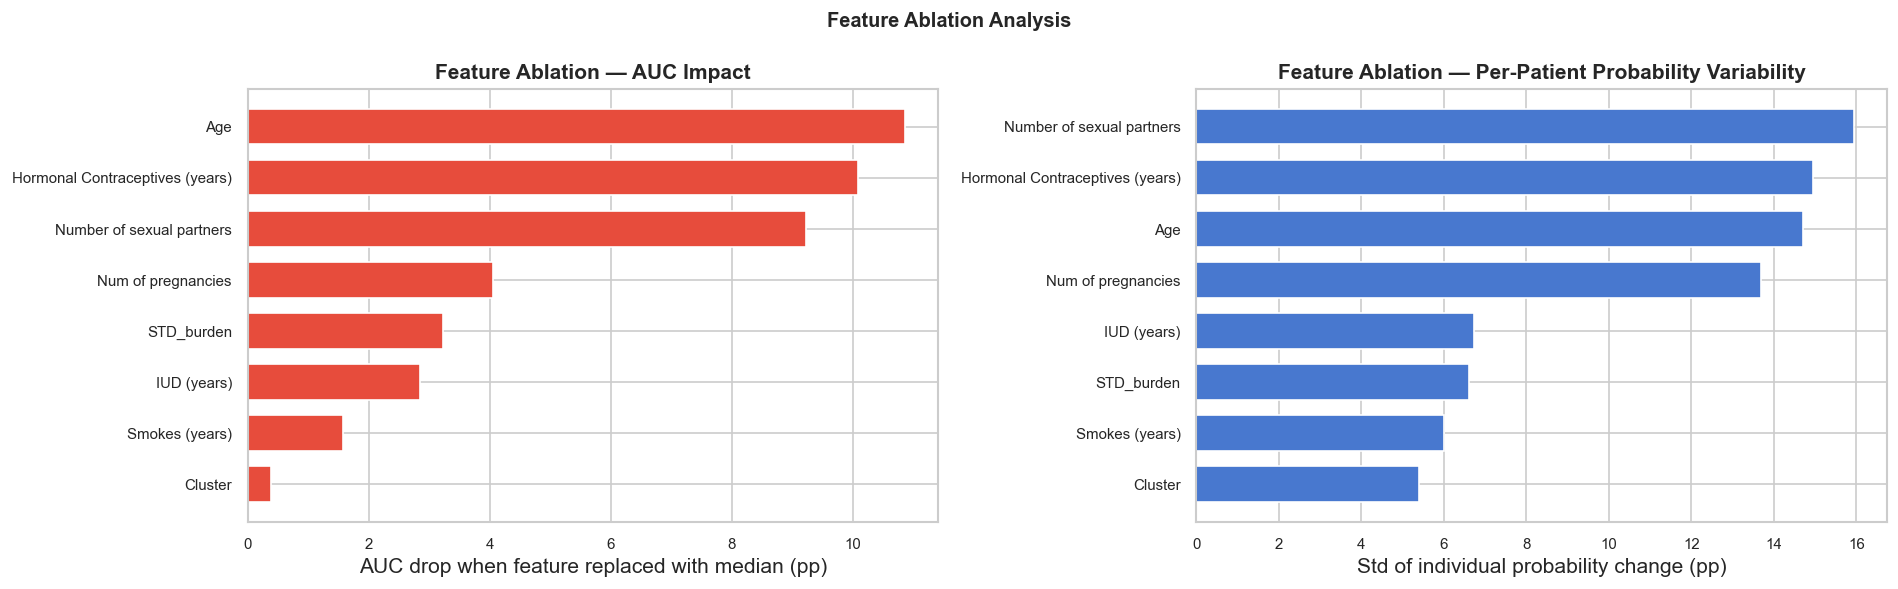

In [10]:
from sklearn.metrics import roc_auc_score

base_auc = roc_auc_score(y, BASE_ENS_P)
ablation_results = {}

for feat in FEATURES:
    X_abl = X.copy()
    X_abl[feat] = X[feat].median()   # replace with median = "remove" the feature's signal
    p_abl       = ensemble_proba(X_abl)
    abl_auc     = roc_auc_score(y, p_abl)
    ablation_results[feat] = {
        'auc_after_ablation': round(abl_auc, 4),
        'auc_drop':           round(base_auc - abl_auc, 4),
        'mean_prob_change_pp':round(float((p_abl - BASE_ENS_P).mean() * 100), 3),
        'std_prob_change':    round(float((p_abl - BASE_ENS_P).std() * 100), 3),
    }

abl_df = pd.DataFrame(ablation_results).T.sort_values('auc_drop', ascending=False)
print(f'Baseline AUC: {base_auc:.4f}')
print('\nFeature ablation results (sorted by AUC drop):')
print(abl_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# AUC drop
abl_sorted = abl_df.sort_values('auc_drop', ascending=True)
axes[0].barh(abl_sorted.index, abl_sorted['auc_drop'] * 100,
             color='#E74C3C', edgecolor='white', height=0.7)
axes[0].axvline(0, color='k', lw=1)
axes[0].set_xlabel('AUC drop when feature replaced with median (pp)')
axes[0].set_title('Feature Ablation — AUC Impact', fontweight='bold')
axes[0].tick_params(labelsize=9)

# Probability variance introduced / removed
abl_sorted2 = abl_df.sort_values('std_prob_change', ascending=True)
axes[1].barh(abl_sorted2.index, abl_sorted2['std_prob_change'],
             color='#4878CF', edgecolor='white', height=0.7)
axes[1].set_xlabel('Std of individual probability change (pp)')
axes[1].set_title('Feature Ablation — Per-Patient Probability Variability', fontweight='bold')
axes[1].tick_params(labelsize=9)

plt.suptitle('Feature Ablation Analysis', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_ablation.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 8. Cluster-Level Sensitivity

The three patient risk clusters from K-Means may respond differently to the same input perturbation. Here we run each scenario per cluster to understand whether uncertainty affects low-risk vs high-risk patients differently.

Mean probability change (pp) per cluster per perturbation:
                         Low Risk  Medium Risk  High Risk
STD_burden → 0             -0.439        0.184     -5.898
Smokes (years) → 0          0.115       -0.716     -0.773
IUD (years) → 0            -0.000       -0.448      0.969
HC (years) doubled          2.684        6.612      2.033
All continuous → median    -8.474       -3.997    -12.441


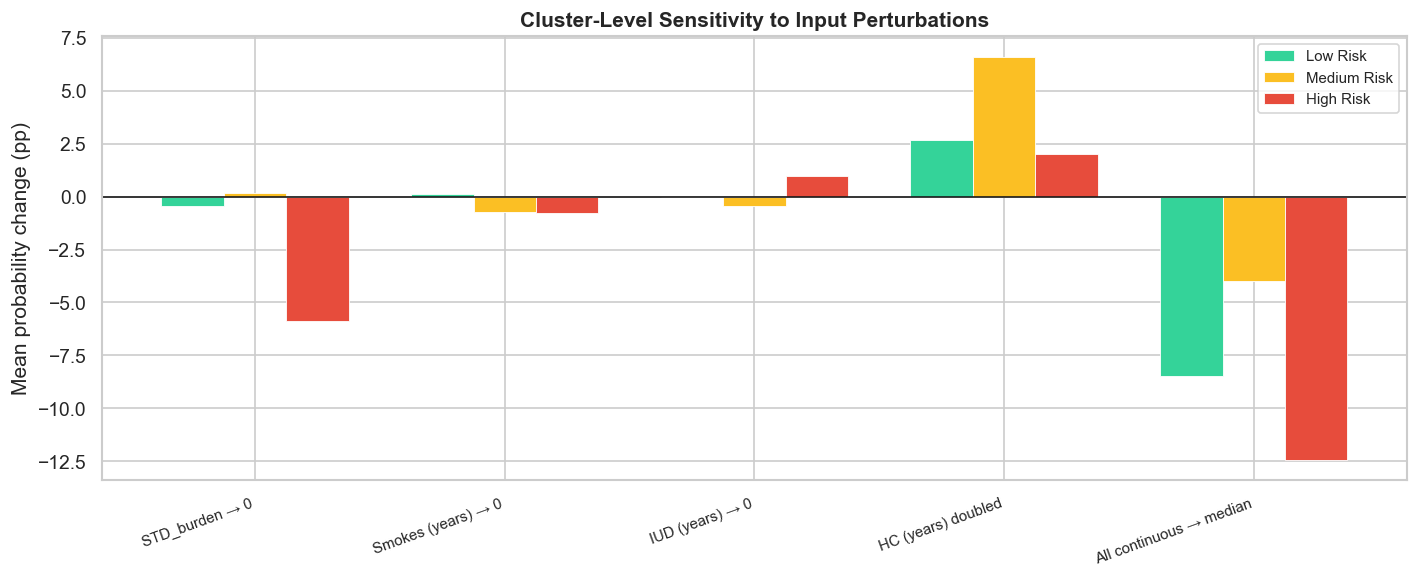


Insight: High-risk cluster should show the largest probability drops when risk factors are hidden.


In [11]:
# Perturbations to test per cluster
perturbations = {
    'STD_burden → 0':           lambda df: df.assign(**{'STD_burden': 0}),
    'Smokes (years) → 0':       lambda df: df.assign(**{'Smokes (years)': 0}),
    'IUD (years) → 0':          lambda df: df.assign(**{'IUD (years)': 0}),
    'HC (years) doubled':       lambda df: df.assign(**{'Hormonal Contraceptives (years)': df['Hormonal Contraceptives (years)']*2}),
    'All continuous → median':  lambda df: df.assign(**{f: X[f].median() for f in FEATURES if f not in ('Cluster',)}),
}

cluster_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
cluster_results = {}

for pert_name, pert_fn in perturbations.items():
    X_pert  = pert_fn(X.copy())
    p_pert  = ensemble_proba(X_pert)
    row = {}
    for c in [0, 1, 2]:
        mask = (df['Cluster'] == c).values
        delta = (p_pert - BASE_ENS_P)[mask].mean() * 100
        flips = ((BASE_PRED[mask]==1) & ((p_pert[mask]>=THRESHOLD)==0)).sum()
        row[cluster_labels[c]] = round(float(delta), 3)
    cluster_results[pert_name] = row

cluster_df = pd.DataFrame(cluster_results).T
print('Mean probability change (pp) per cluster per perturbation:')
print(cluster_df.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(cluster_results))
width = 0.25
colors_clust = ['#34d399', '#fbbf24', '#E74C3C']

for i, col in enumerate(cluster_df.columns):
    ax.bar(x_pos + i*width, cluster_df[col], width, label=col,
           color=colors_clust[i], edgecolor='white', linewidth=0.5)

ax.axhline(0, color='k', lw=1)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(cluster_df.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Mean probability change (pp)')
ax.set_title('Cluster-Level Sensitivity to Input Perturbations', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'cluster_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nInsight: High-risk cluster should show the largest probability drops when risk factors are hidden.')

---
## 9. Confidence Score Stress Test

Which input perturbations destabilise the confidence score the most?  
A large drop in confidence when a feature is perturbed means the DSS should flag that input as uncertain.

Confidence score sensitivity per feature (ablation to median):
                                 mean_conf_change  std_conf_change  pct_drop_>0.1  pct_drop_>0.2
Num of pregnancies                        -0.1033           0.3727           22.3           17.8
Smokes (years)                            -0.0131           0.1533            3.5            2.6
IUD (years)                               -0.0042           0.1223            2.4            2.1
STD_burden                                -0.0026           0.0904            2.9            1.4
Number of sexual partners                  0.0007           0.3422           15.7           11.3
Hormonal Contraceptives (years)            0.0041           0.3918           19.9           12.7
Age                                        0.0125           0.3567           17.7           12.6
Cluster                                    0.0141           0.2203           11.0            3.8


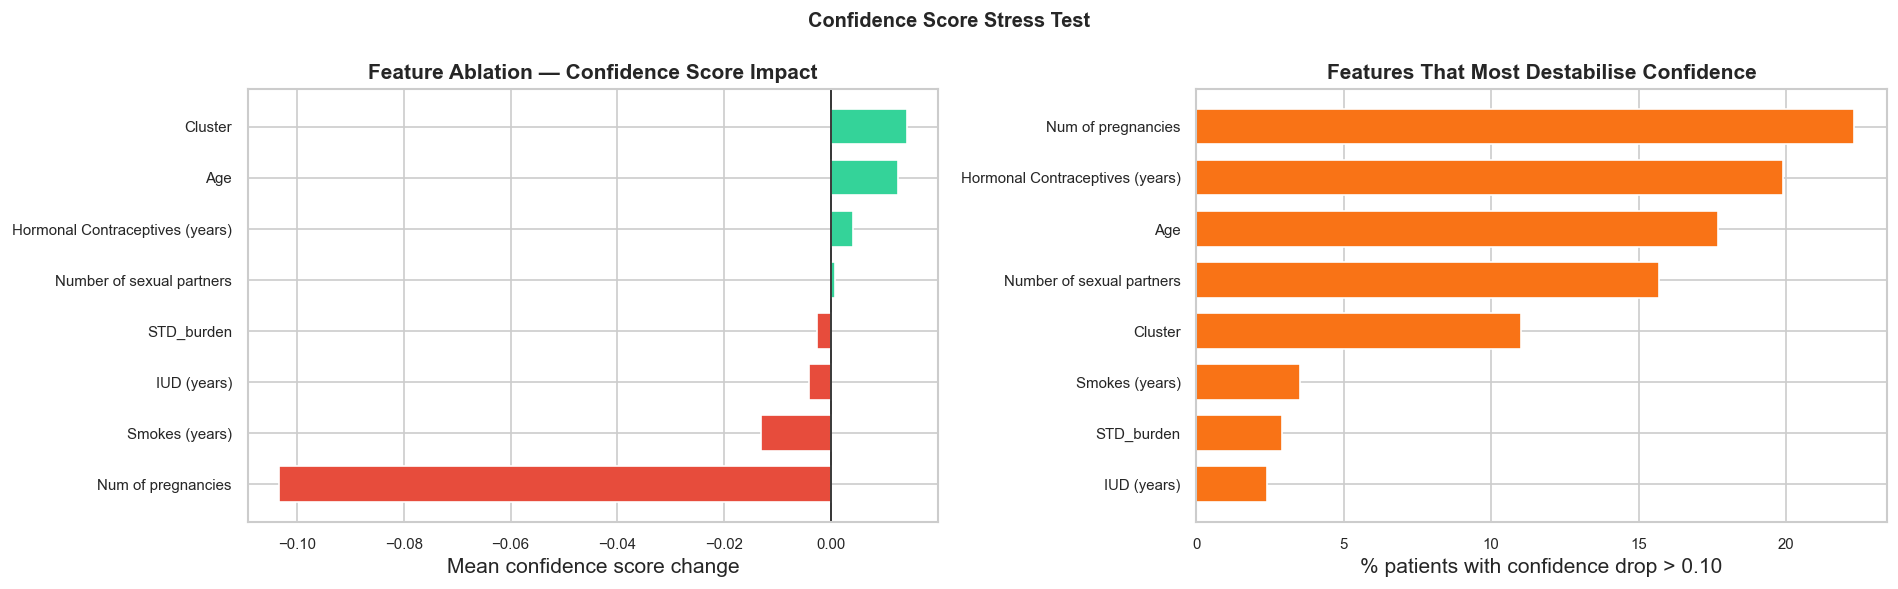

In [12]:
conf_stress = {}

for feat in FEATURES:
    X_pt = X.copy()
    X_pt[feat] = X[feat].median()
    p_pt   = ensemble_proba(X_pt)
    ind_pt = individual_probas(X_pt)
    conf_pt = compute_confidence_batch(X_pt, p_pt, ind_pt)
    delta_conf = conf_pt - BASE_CONF
    conf_stress[feat] = {
        'mean_conf_change':   round(float(delta_conf.mean()), 4),
        'std_conf_change':    round(float(delta_conf.std()),  4),
        'pct_drop_>0.1':      round(float((delta_conf < -0.10).mean() * 100), 1),
        'pct_drop_>0.2':      round(float((delta_conf < -0.20).mean() * 100), 1),
    }

conf_df = pd.DataFrame(conf_stress).T.sort_values('mean_conf_change')
print('Confidence score sensitivity per feature (ablation to median):')
print(conf_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean confidence change
colors_conf = ['#E74C3C' if v < 0 else '#34d399' for v in conf_df['mean_conf_change']]
axes[0].barh(conf_df.index, conf_df['mean_conf_change'],
             color=colors_conf, edgecolor='white', height=0.7)
axes[0].axvline(0, color='k', lw=1)
axes[0].set_xlabel('Mean confidence score change')
axes[0].set_title('Feature Ablation — Confidence Score Impact', fontweight='bold')
axes[0].tick_params(labelsize=9)

# % patients with >0.1 confidence drop
conf_sorted = conf_df.sort_values('pct_drop_>0.1', ascending=True)
axes[1].barh(conf_sorted.index, conf_sorted['pct_drop_>0.1'],
             color='#f97316', edgecolor='white', height=0.7)
axes[1].set_xlabel('% patients with confidence drop > 0.10')
axes[1].set_title('Features That Most Destabilise Confidence', fontweight='bold')
axes[1].tick_params(labelsize=9)

plt.suptitle('Confidence Score Stress Test', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confidence_stress.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 10. Missing Data Simulation

**Clinical scenario:** At a real clinic, not every field will be filled in. We simulate what happens when 1, 2, 3, or more features are unknown (replaced by their median) — how much does AUC and confidence degrade?

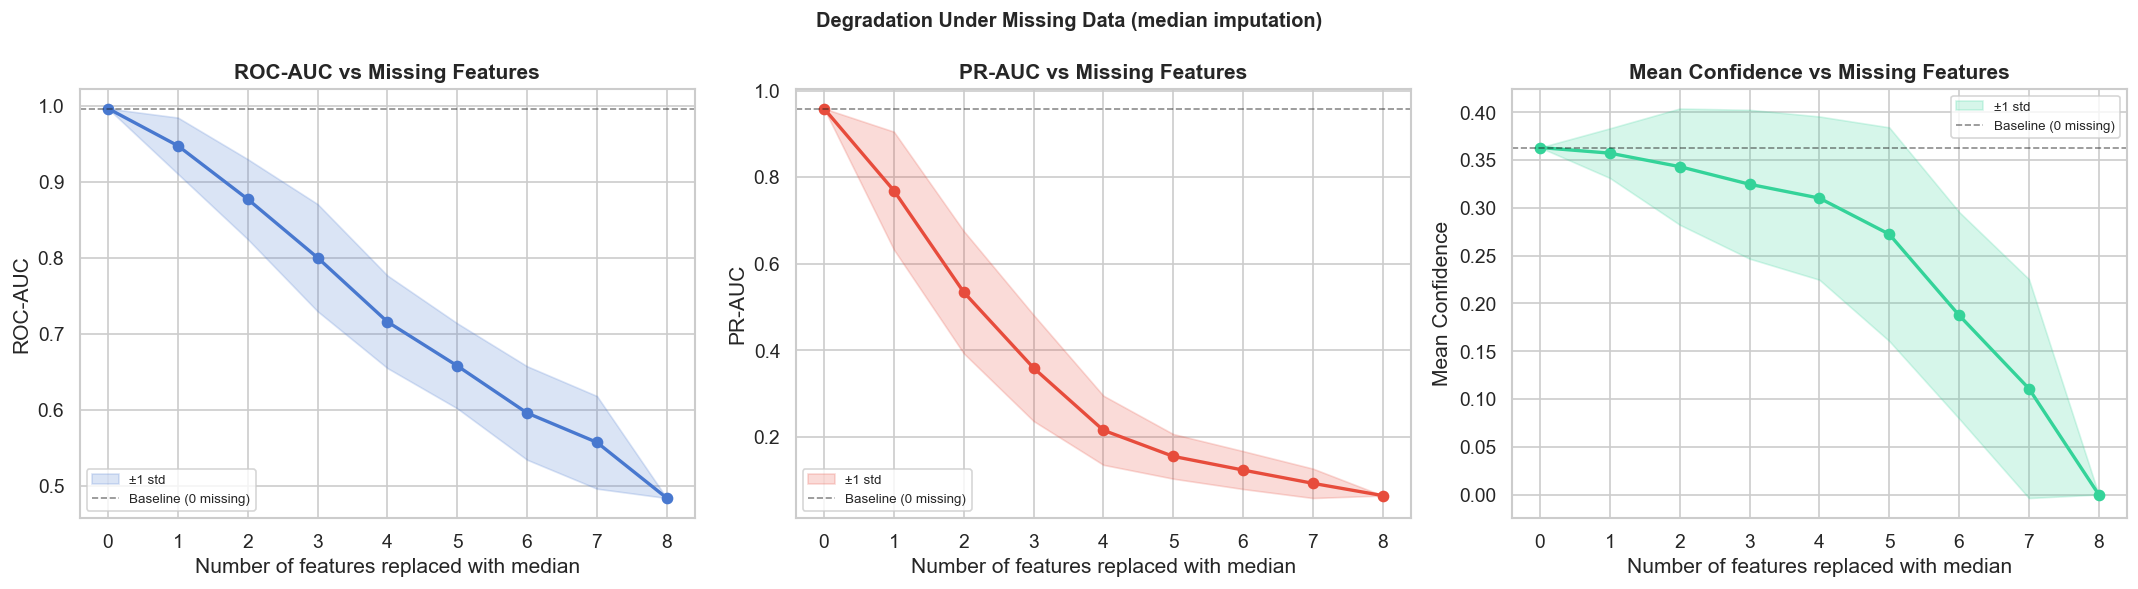


Missing data summary:
   n_missing  auc_mean  prauc_mean  conf_mean
0          0    0.9969      0.9586     0.3632
1          1    0.9479      0.7689     0.3573
2          2    0.8775      0.5343     0.3432
3          3    0.8004      0.3590     0.3247
4          4    0.7160      0.2150     0.3102
5          5    0.6580      0.1547     0.2725
6          6    0.5958      0.1230     0.1877
7          7    0.5571      0.0924     0.1109
8          8    0.4838      0.0641     0.0000

DSS can tolerate up to 1 missing features before AUC drops >5%.


In [13]:
from sklearn.metrics import average_precision_score

N_REPS = 50   # random feature subsets per missing count
rng    = np.random.default_rng(SEED)

missing_sweep = []

for n_missing in range(0, len(FEATURES) + 1):
    aucs, prauc, confs = [], [], []
    for _ in range(N_REPS if n_missing > 0 else 1):
        feats_to_blank = rng.choice(FEATURES, size=n_missing, replace=False)
        X_miss = X.copy()
        for f in feats_to_blank:
            X_miss[f] = X[f].median()
        p_miss   = ensemble_proba(X_miss)
        ind_miss = individual_probas(X_miss)
        conf_miss = compute_confidence_batch(X_miss, p_miss, ind_miss)
        aucs.append(roc_auc_score(y, p_miss))
        prauc.append(average_precision_score(y, p_miss))
        confs.append(conf_miss.mean())

    missing_sweep.append({
        'n_missing':    n_missing,
        'auc_mean':     np.mean(aucs),
        'auc_std':      np.std(aucs),
        'prauc_mean':   np.mean(prauc),
        'prauc_std':    np.std(prauc),
        'conf_mean':    np.mean(confs),
        'conf_std':     np.std(confs),
    })

miss_df = pd.DataFrame(missing_sweep)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, label, color in [
    (axes[0], 'auc',   'ROC-AUC',       '#4878CF'),
    (axes[1], 'prauc', 'PR-AUC',         '#E74C3C'),
    (axes[2], 'conf',  'Mean Confidence','#34d399'),
]:
    ax.plot(miss_df['n_missing'], miss_df[f'{metric}_mean'],
            'o-', color=color, lw=2, markersize=6)
    ax.fill_between(
        miss_df['n_missing'],
        miss_df[f'{metric}_mean'] - miss_df[f'{metric}_std'],
        miss_df[f'{metric}_mean'] + miss_df[f'{metric}_std'],
        alpha=0.2, color=color, label='±1 std'
    )
    ax.axhline(miss_df[f'{metric}_mean'].iloc[0], color='k', ls='--',
               lw=1, alpha=0.5, label='Baseline (0 missing)')
    ax.set_xlabel('Number of features replaced with median')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs Missing Features', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xticks(range(len(FEATURES)+1))

plt.suptitle('Degradation Under Missing Data (median imputation)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'missing_data_simulation.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nMissing data summary:')
print(miss_df[['n_missing','auc_mean','prauc_mean','conf_mean']].round(4).to_string())

# Acceptable degradation threshold (5% AUC drop)
acceptable = miss_df[miss_df['auc_mean'] >= base_auc * 0.95]['n_missing'].max()
print(f'\nDSS can tolerate up to {acceptable} missing features before AUC drops >5%.')

---
## 11. Hormonal Contraceptives Duration Sweep

HC use is one of the top correlates from the EDA. We test how predicted risk changes across the full range of HC duration for an otherwise median patient.

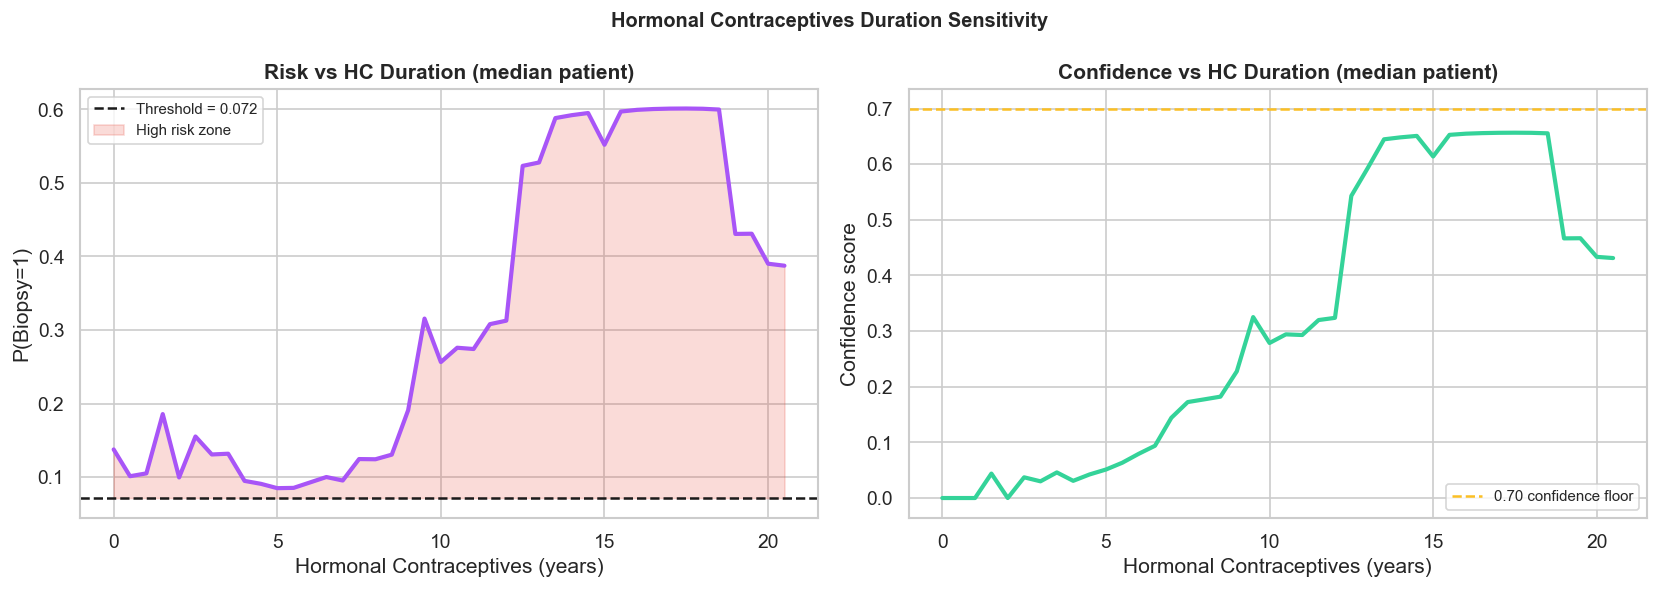

In [14]:
hc_range    = np.arange(0, 21, 0.5)
median_pat  = X.median().to_dict()

hc_probs, hc_confs = [], []
for hc_val in hc_range:
    row = pd.DataFrame([{**median_pat, 'Hormonal Contraceptives (years)': hc_val}])[FEATURES]
    p   = float(ensemble_proba(row)[0])
    ind = {n: float(MODELS[n].predict_proba(row)[0,1]) for n in MODEL_NAMES}
    c   = float(compute_confidence_batch(row, np.array([p]), {n: np.array([v]) for n,v in ind.items()})[0])
    hc_probs.append(p)
    hc_confs.append(c)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hc_range, hc_probs, color='#a855f7', lw=2.5)
axes[0].axhline(THRESHOLD, color='k', ls='--', lw=1.5,
                label=f'Threshold = {THRESHOLD:.3f}')
axes[0].fill_between(hc_range, hc_probs, THRESHOLD,
                     where=np.array(hc_probs) >= THRESHOLD,
                     alpha=0.2, color='#E74C3C', label='High risk zone')
axes[0].set_xlabel('Hormonal Contraceptives (years)')
axes[0].set_ylabel('P(Biopsy=1)')
axes[0].set_title('Risk vs HC Duration (median patient)', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(hc_range, hc_confs, color='#34d399', lw=2.5)
axes[1].axhline(0.70, color='#fbbf24', ls='--', lw=1.5, label='0.70 confidence floor')
axes[1].set_xlabel('Hormonal Contraceptives (years)')
axes[1].set_ylabel('Confidence score')
axes[1].set_title('Confidence vs HC Duration (median patient)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Hormonal Contraceptives Duration Sensitivity', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'hc_duration_sweep.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 12. Key Findings Summary — DSS Intervention Rules

Collects all sensitivity findings into a structured table for the DSS write-up.

DSS SENSITIVITY FINDINGS — INTERVENTION RULES

[High]  STD misreporting (all → 0)
  Finding: 4 high-risk patients flip to low-risk (0.6% of high-risk pool)
  DSS Rule: Flag prediction if STD_burden = 0 and ≥2 other risk factors are elevated

[Medium]  Smoking status unknown (→ 0)
  Finding: Mean probability shift: -0.19 pp; 6 flips to low-risk
  DSS Rule: If patient is a known smoker, do not allow blank smoking duration; default to median imputation with warning

[Medium]  IUD not recorded (→ 0)
  Finding: Mean shift: -0.08 pp; 9 flips to high-risk
  DSS Rule: Missing IUD duration inflates risk. Prompt staff to verify IUD status before finalising prediction

[High]  Missing features (median imputation)
  Finding: Up to 1 features can be missing before AUC drops >5%
  DSS Rule: Show completeness score in UI. Flag predictions when >=2 features are missing

[High]  Feature most critical for confidence
  Finding: Num of pregnancies causes the largest average confidence drop when removed
  

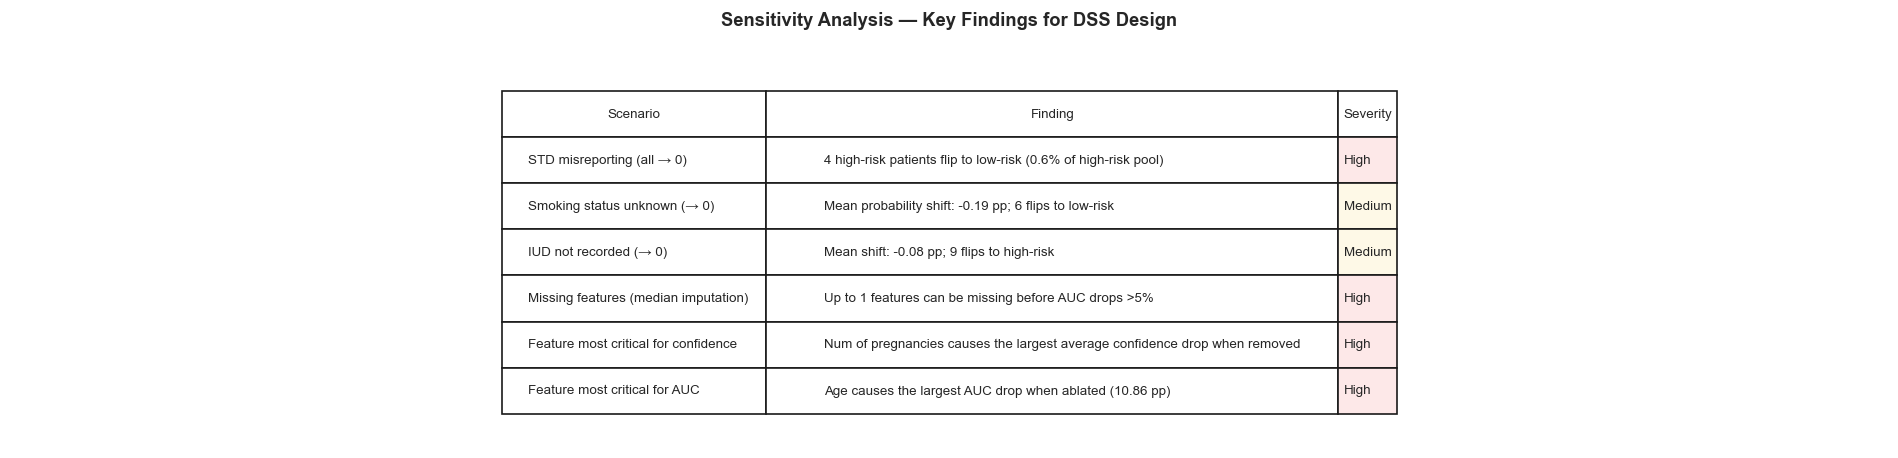

In [15]:
# ── Collect key numbers across all analyses ───────────────────────────────────
findings = [
    {
        'Scenario': 'STD misreporting (all → 0)',
        'Finding': f"{flipped} high-risk patients flip to low-risk ({flipped/max(BASE_PRED.sum(),1):.1%} of high-risk pool)",
        'DSS Rule': 'Flag prediction if STD_burden = 0 and ≥2 other risk factors are elevated',
        'Severity': 'High',
    },
    {
        'Scenario': 'Smoking status unknown (→ 0)',
        'Finding': f"Mean probability shift: {smoke_results['Unknown (→ 0)']['delta_pp']:+.2f} pp; "
                   f"{smoke_results['Unknown (→ 0)']['flips_to_low']} flips to low-risk",
        'DSS Rule': 'If patient is a known smoker, do not allow blank smoking duration; default to median imputation with warning',
        'Severity': 'Medium',
    },
    {
        'Scenario': 'IUD not recorded (→ 0)',
        'Finding': f"Mean shift: {iud_results['IUD not recorded (→0)']['delta_pp']:+.2f} pp; "
                   f"{iud_results['IUD not recorded (→0)']['flips_to_high']} flips to high-risk",
        'DSS Rule': 'Missing IUD duration inflates risk. Prompt staff to verify IUD status before finalising prediction',
        'Severity': 'Medium',
    },
    {
        'Scenario': 'Missing features (median imputation)',
        'Finding': f"Up to {acceptable} features can be missing before AUC drops >5%",
        'DSS Rule': f'Show completeness score in UI. Flag predictions when >={acceptable+1} features are missing',
        'Severity': 'High' if acceptable < 3 else 'Medium',
    },
    {
        'Scenario': 'Feature most critical for confidence',
        'Finding': f"{conf_df.index[0]} causes the largest average confidence drop when removed",
        'DSS Rule': f'Make {conf_df.index[0]} a required field in the DSS intake form',
        'Severity': 'High',
    },
    {
        'Scenario': 'Feature most critical for AUC',
        'Finding': f"{abl_df.index[0]} causes the largest AUC drop when ablated ({abl_df['auc_drop'].iloc[0]*100:.2f} pp)",
        'DSS Rule': f'Collect {abl_df.index[0]} first during intake; prioritise its accuracy',
        'Severity': 'High',
    },
]

findings_df = pd.DataFrame(findings)
print('=' * 90)
print('DSS SENSITIVITY FINDINGS — INTERVENTION RULES')
print('=' * 90)
for _, row in findings_df.iterrows():
    print(f'\n[{row["Severity"]}]  {row["Scenario"]}')
    print(f'  Finding: {row["Finding"]}')
    print(f'  DSS Rule: {row["DSS Rule"]}')

# Visual summary table
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')
tbl = ax.table(
    cellText=findings_df[['Scenario','Finding','Severity']].values,
    colLabels=['Scenario', 'Finding', 'Severity'],
    loc='center', cellLoc='left',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 2.2)
tbl.auto_set_column_width([0, 1, 2])
# Colour severity cells
for (r, c), cell in tbl.get_celld().items():
    if c == 2 and r > 0:
        val = findings_df['Severity'].iloc[r-1]
        cell.set_facecolor('#fde8e8' if val == 'High' else '#fef9e7')
ax.set_title('Sensitivity Analysis — Key Findings for DSS Design',
             fontweight='bold', fontsize=11, pad=20)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'findings_summary.png', dpi=130, bbox_inches='tight')
plt.show()

In [16]:
# ── Save sensitivity results ──────────────────────────────────────────────────
sensitivity_output = {
    'baseline': {
        'auc':            round(float(base_auc), 4),
        'mean_prob':      round(float(BASE_ENS_P.mean()), 4),
        'high_risk_count':int(BASE_PRED.sum()),
        'threshold':      round(float(THRESHOLD), 4),
    },
    'std_misreporting': {
        'flips_at_100pct_misreport': int(flipped),
        'scale_factor_results': {str(k): v for k, v in results_scale.items()},
    },
    'smoking': smoke_results,
    'iud':     iud_results,
    'ablation_auc_drop':   abl_df['auc_drop'].round(4).to_dict(),
    'confidence_stress':   conf_df['mean_conf_change'].round(4).to_dict(),
    'missing_data': miss_df[['n_missing','auc_mean','prauc_mean','conf_mean']].round(4).to_dict('records'),
    'max_missing_features_before_5pct_auc_drop': int(acceptable),
    'intervention_rules': findings_df.to_dict('records'),
}

Path('cervical_sensitivity_results.json').write_text(
    json.dumps(sensitivity_output, indent=2, default=str)
)
print('✅  Sensitivity results saved → cervical_sensitivity_results.json')
print(f'    Plots saved → ./{PLOTS_DIR}/')
print(f'    Total plots: {len(list(PLOTS_DIR.glob("*.png")))}')

✅  Sensitivity results saved → cervical_sensitivity_results.json
    Plots saved → ./sensitivity_plots/
    Total plots: 11
